In [1]:
import subprocess
import os
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

In [2]:
VIDEO_DIR = Path("fineVideos")
video_files = sorted(VIDEO_DIR.glob("*.mp4"))
print(f"Found {len(video_files)} video files")

Found 43751 video files


In [3]:
def get_duration(filepath: Path) -> float | None:
    """Return duration in seconds using ffprobe, or None on failure."""
    try:
        result = subprocess.run(
            [
                "ffprobe", "-v", "error",
                "-show_entries", "format=duration",
                "-of", "default=noprint_wrappers=1:nokey=1",
                str(filepath),
            ],
            capture_output=True, text=True, timeout=10,
        )
        return float(result.stdout.strip())
    except Exception:
        return None

In [4]:
results = []
NUM_WORKERS = 16

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {executor.submit(get_duration, f): f for f in video_files}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Probing durations"):
        filepath = futures[future]
        duration = future.result()
        results.append({"filename": filepath.name, "duration_sec": duration})

df = pd.DataFrame(results)
print(f"Successfully probed: {df['duration_sec'].notna().sum()} / {len(df)}")

Probing durations: 100%|██████████| 43751/43751 [01:10<00:00, 624.21it/s]

Successfully probed: 43751 / 43751


In [5]:
df_sorted = df.dropna(subset=["duration_sec"]).sort_values("duration_sec", ascending=False).reset_index(drop=True)
df_sorted.index += 1
df_sorted.index.name = "rank"
df_sorted

,filename,duration_sec
rank,,
1,RvSlBN9nINU.mp4,659.470000
2,FwFJ8Aart6o.mp4,659.446641
3,Te5DA8FVCUc.mp4,659.377033
4,dN9q2Rr2lAc.mp4,659.377018
5,7CB1ndH8DqI.mp4,659.354000
...,...,...
43747,1w5qVzt6UNU.mp4,14.721419
43748,M2oHHqlRYzA.mp4,14.651767
43749,09V4prc98pQ.mp4,14.187370


In [6]:
print(f"Total clips:     {len(df_sorted)}")
print(f"Longest clip:    {df_sorted['duration_sec'].iloc[0]:.2f}s  ({df_sorted['filename'].iloc[0]})")
print(f"Shortest clip:   {df_sorted['duration_sec'].iloc[-1]:.2f}s  ({df_sorted['filename'].iloc[-1]})")
print(f"Mean duration:   {df_sorted['duration_sec'].mean():.2f}s")
print(f"Median duration: {df_sorted['duration_sec'].median():.2f}s")
print(f"Std deviation:   {df_sorted['duration_sec'].std():.2f}s")

Total clips:     43751
Longest clip:    659.47s  (RvSlBN9nINU.mp4)
Shortest clip:   13.93s  (vx7CK07WKss.mp4)
Mean duration:   283.38s
Median duration: 248.80s
Std deviation:   190.79s


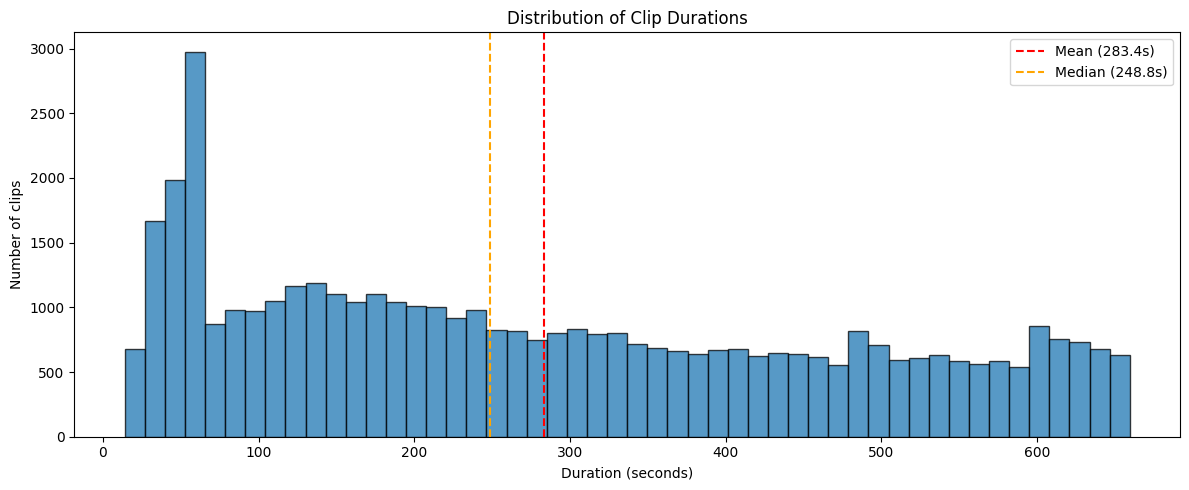

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_sorted["duration_sec"], bins=50, edgecolor="black", alpha=0.75)
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Number of clips")
ax.set_title("Distribution of Clip Durations")
ax.axvline(df_sorted["duration_sec"].mean(), color="red", linestyle="--", label=f"Mean ({df_sorted['duration_sec'].mean():.1f}s)")
ax.axvline(df_sorted["duration_sec"].median(), color="orange", linestyle="--", label=f"Median ({df_sorted['duration_sec'].median():.1f}s)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
df_sorted.to_csv("clip_durations_sorted.csv", index=True)
print("Saved to clip_durations_sorted.csv")

Saved to clip_durations_sorted.csv


In [9]:
import shutil

out_dir = Path("test_videos")
out_dir.mkdir(exist_ok=True)

top5 = df_sorted.head(5)
for _, row in top5.iterrows():
    src = VIDEO_DIR / row["filename"]
    dst = out_dir / row["filename"]
    shutil.copy2(src, dst)
    print(f"Copied {row['filename']}  ({row['duration_sec']:.2f}s)")

print(f"\nSaved {len(top5)} clips to {out_dir}/")


Copied RvSlBN9nINU.mp4  (659.47s)
Copied FwFJ8Aart6o.mp4  (659.45s)
Copied Te5DA8FVCUc.mp4  (659.38s)
Copied dN9q2Rr2lAc.mp4  (659.38s)
Copied 7CB1ndH8DqI.mp4  (659.35s)

Saved 5 clips to test_videos/
